# Exploratory Data Analysis (EDA) for Electricity Load Diagrams Dataset

This notebook performs exploratory data analysis on the multivariate time series dataset of electricity load diagrams from 2011-2014. The dataset contains electricity consumption readings from 370 meters recorded every 15 minutes.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Load the Dataset

Load the electricity load diagrams dataset. Due to the large size of the file, we'll sample the first 10,000 rows for this EDA.

In [2]:
# Load the dataset (sample first 10,000 rows to manage memory)
file_path = '/workspaces/KARMA-/data/raw/electricityloaddiagrams/LD2011_2014.txt'
df = pd.read_csv(file_path, sep=';', nrows=10000, decimal=',')

# Parse the timestamp column
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])

# Set the timestamp as index
df.set_index(df.columns[0], inplace=True)
df.index.name = 'timestamp'

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Columns: {list(df.columns[:5])}... (showing first 5)")

Dataset shape: (10000, 370)
Date range: 2011-01-01 00:15:00 to 2011-04-15 04:00:00
Columns: ['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005']... (showing first 5)


## 3. Data Overview and Summary Statistics

In [3]:
# Display first few rows
print("First 5 rows:")
display(df.head())

# Data types and info
print("\nData types:")
print(df.dtypes)

# Summary statistics
print("\nSummary statistics:")
display(df.describe())

# Check for missing values
print("\nMissing values per column:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

First 5 rows:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Data types:
MT_001    int64
MT_002    int64
MT_003    int64
MT_004    int64
MT_005    int64
          ...  
MT_366    int64
MT_367    int64
MT_368    int64
MT_369    int64
MT_370    int64
Length: 370, dtype: object

Summary statistics:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,...,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Missing values per column:
Series([], dtype: int64)


## 4. Handle Missing Values

In [4]:
# Check percentage of zeros (which might indicate missing data)
zero_percentage = (df == 0).sum() / len(df) * 100
print("Percentage of zeros per column:")
print(zero_percentage.sort_values(ascending=False).head(10))

# For time series data, we'll use forward fill for missing values
df_filled = df.fillna(method='ffill')

# Verify no missing values remain
print(f"\nMissing values after forward fill: {df_filled.isnull().sum().sum()}")

Percentage of zeros per column:
MT_370    100.0
MT_001    100.0
MT_002    100.0
MT_003    100.0
MT_004    100.0
MT_005    100.0
MT_006    100.0
MT_007    100.0
MT_008    100.0
MT_009    100.0
dtype: float64

Missing values after forward fill: 0


## 5. Visualize Time Series Trends

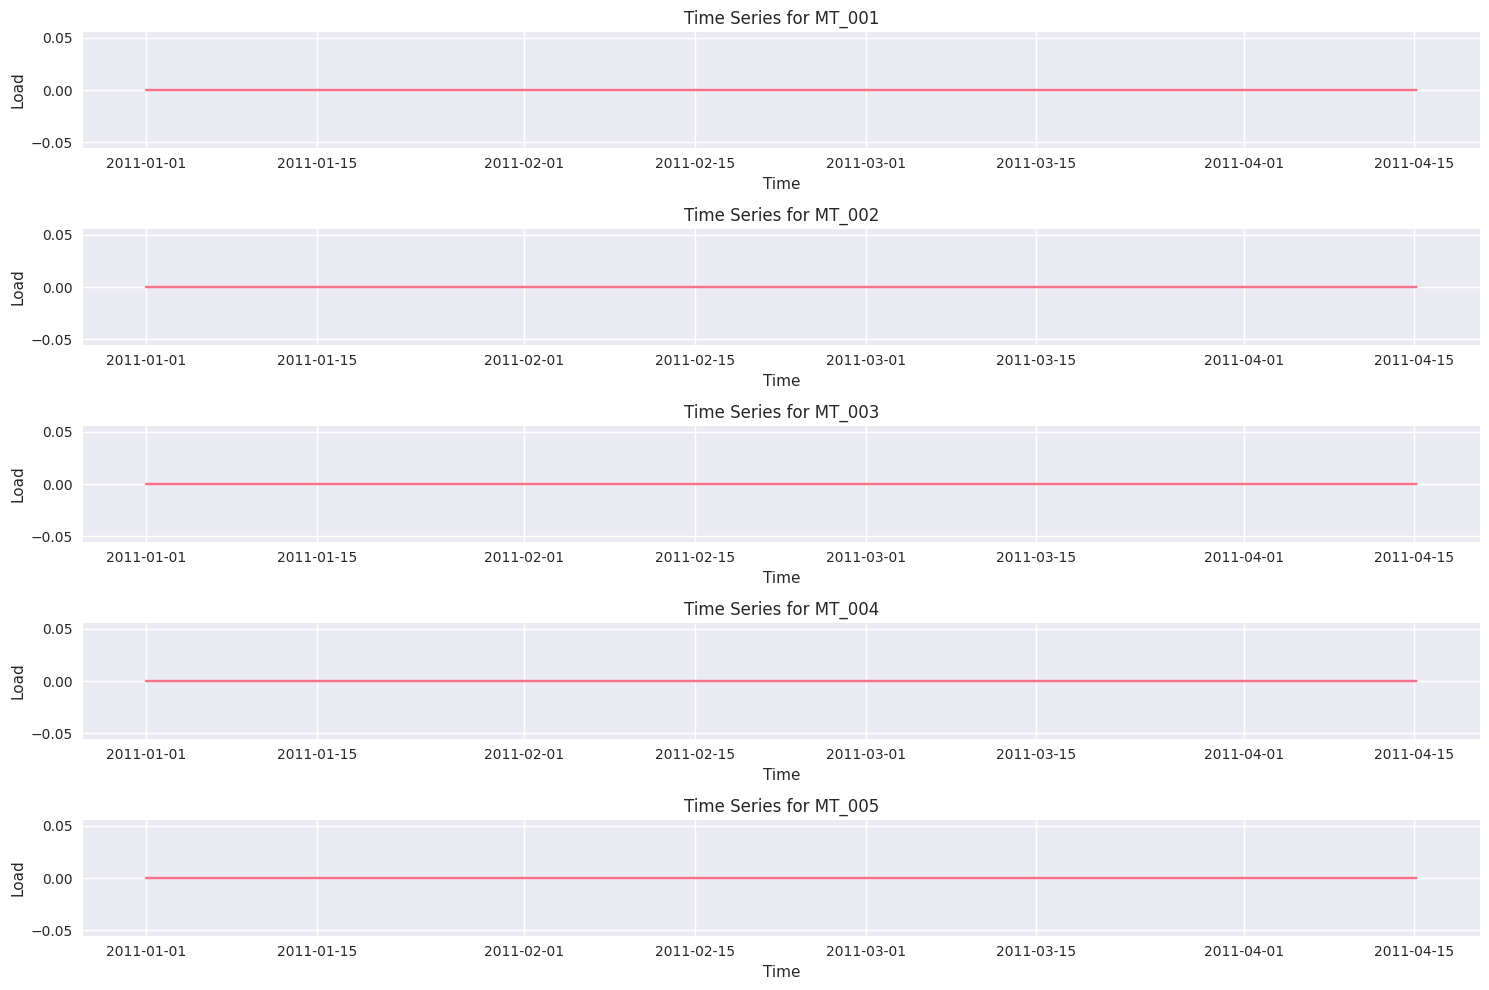

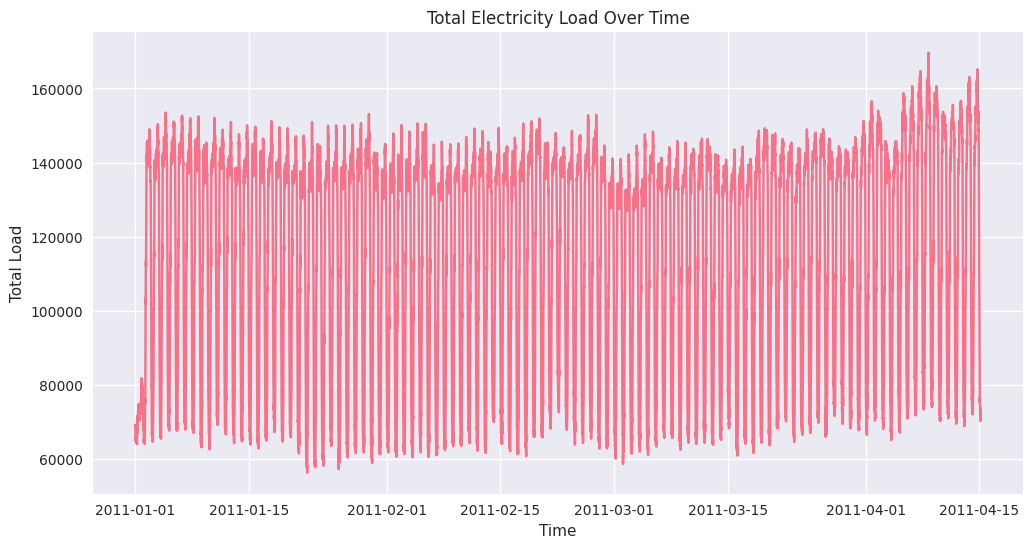

In [5]:
# Plot time series for a few selected meters
selected_meters = df_filled.columns[:5]  # First 5 meters

plt.figure(figsize=(15, 10))
for i, meter in enumerate(selected_meters, 1):
    plt.subplot(5, 1, i)
    plt.plot(df_filled.index, df_filled[meter])
    plt.title(f'Time Series for {meter}')
    plt.xlabel('Time')
    plt.ylabel('Load')
plt.tight_layout()
plt.show()

# Plot overall load (sum of all meters)
total_load = df_filled.sum(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(df_filled.index, total_load)
plt.title('Total Electricity Load Over Time')
plt.xlabel('Time')
plt.ylabel('Total Load')
plt.show()

## 6. Analyze Correlations Between Variables

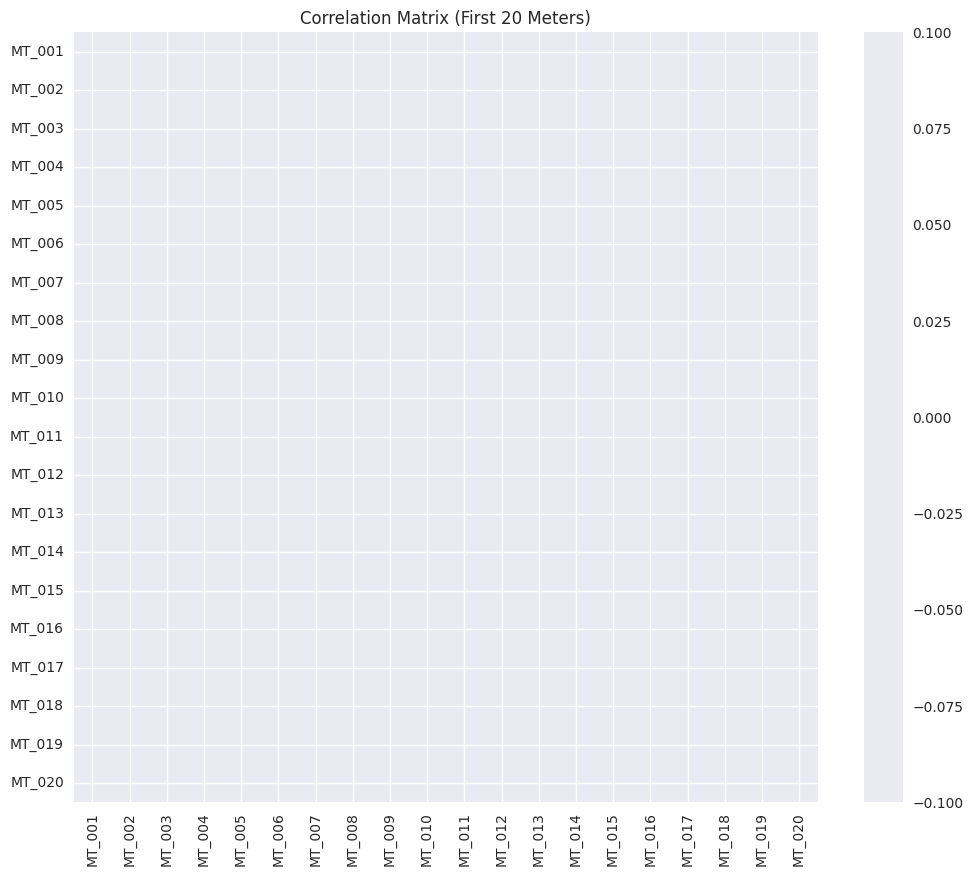

Top 10 highly correlated pairs:
Series([], dtype: float64)


In [6]:
# Compute correlation matrix for first 20 meters (due to computational constraints)
subset_df = df_filled.iloc[:, :20]
corr_matrix = subset_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (First 20 Meters)')
plt.show()

# Find highly correlated pairs
high_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
high_corr_pairs = high_corr.stack().sort_values(ascending=False).head(10)
print("Top 10 highly correlated pairs:")
print(high_corr_pairs)

## 7. Seasonal Decomposition

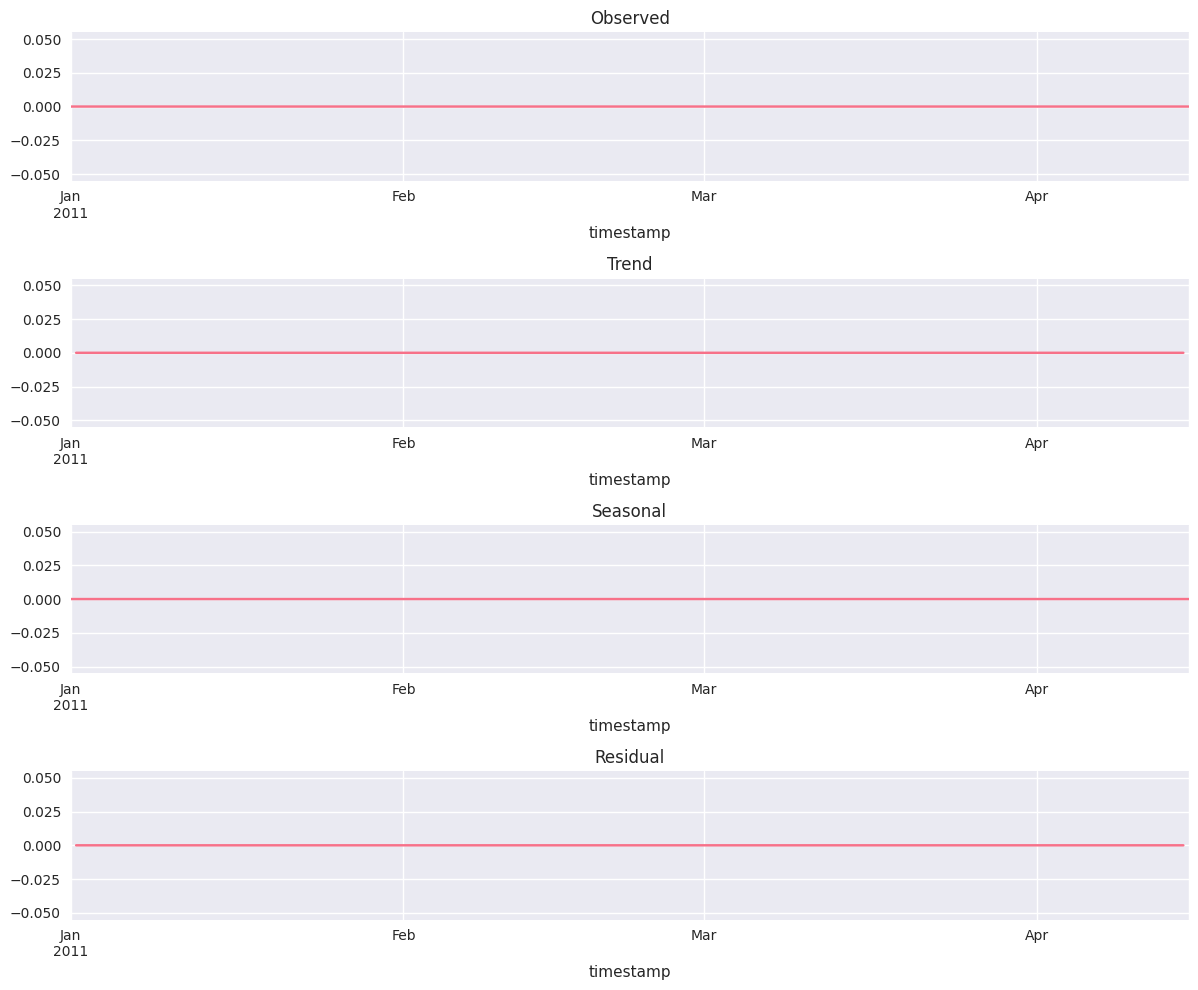

In [7]:
# Perform seasonal decomposition on one meter (assuming daily seasonality)
# Resample to hourly data for decomposition
meter_data = df_filled[df_filled.columns[0]].resample('H').mean()

# Seasonal decomposition
decomposition = seasonal_decompose(meter_data, model='additive', period=24)  # 24 hours

# Plot decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=ax1)
ax1.set_title('Observed')
decomposition.trend.plot(ax=ax2)
ax2.set_title('Trend')
decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
decomposition.resid.plot(ax=ax4)
ax4.set_title('Residual')
plt.tight_layout()
plt.show()

## 8. Outlier Detection

Number of outliers detected: 0
Outlier percentage: 0.00%


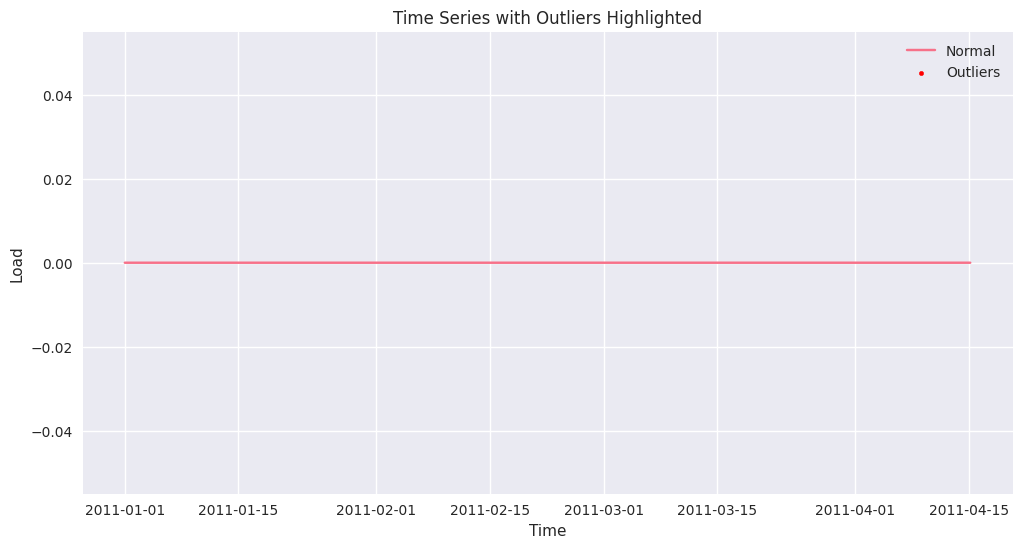

In [8]:
# Outlier detection using IQR method for one meter
meter_data = df_filled[df_filled.columns[0]]

Q1 = meter_data.quantile(0.25)
Q3 = meter_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = meter_data[(meter_data < lower_bound) | (meter_data > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Outlier percentage: {len(outliers)/len(meter_data)*100:.2f}%")

# Plot with outliers highlighted
plt.figure(figsize=(12, 6))
plt.plot(meter_data.index, meter_data, label='Normal')
plt.scatter(outliers.index, outliers.values, color='red', label='Outliers', s=10)
plt.title('Time Series with Outliers Highlighted')
plt.xlabel('Time')
plt.ylabel('Load')
plt.legend()
plt.show()

## 9. Feature Engineering for Time Series

In [9]:
# Create time-based features
df_features = df_filled.copy()
df_features['hour'] = df_features.index.hour
df_features['day_of_week'] = df_features.index.dayofweek
df_features['month'] = df_features.index.month
df_features['is_weekend'] = df_features.index.dayofweek >= 5

# Create rolling statistics for one meter
meter_col = df_features.columns[0]
df_features[f'{meter_col}_rolling_mean_4'] = df_features[meter_col].rolling(window=4).mean()
df_features[f'{meter_col}_rolling_std_4'] = df_features[meter_col].rolling(window=4).std()

# Create lag features
df_features[f'{meter_col}_lag_1'] = df_features[meter_col].shift(1)
df_features[f'{meter_col}_lag_4'] = df_features[meter_col].shift(4)

print("New features created:")
new_features = [col for col in df_features.columns if col not in df_filled.columns]
print(new_features)

# Display sample of engineered features
display(df_features[[meter_col, f'{meter_col}_rolling_mean_4', f'{meter_col}_lag_1', 'hour', 'day_of_week']].head(10))

New features created:
['hour', 'day_of_week', 'month', 'is_weekend', 'MT_001_rolling_mean_4', 'MT_001_rolling_std_4', 'MT_001_lag_1', 'MT_001_lag_4']


,MT_001,MT_001_rolling_mean_4,MT_001_lag_1,hour,day_of_week
timestamp,,,,,
2011-01-01 00:15:00,0,NaN,NaN,0,5
2011-01-01 00:30:00,0,NaN,0.0,0,5
2011-01-01 00:45:00,0,NaN,0.0,0,5
2011-01-01 01:00:00,0,0.0,0.0,1,5
2011-01-01 01:15:00,0,0.0,0.0,1,5
2011-01-01 01:30:00,0,0.0,0.0,1,5
2011-01-01 01:45:00,0,0.0,0.0,1,5
2011-01-01 02:00:00,0,0.0,0.0,2,5
2011-01-01 02:15:00,0,0.0,0.0,2,5
